# KU Leuven battery-electric vehicle sessions

This notebook lists the two vehicles and their sessions, loads one vehicle's slow-charging sessions, and plots SOC through one session. It makes no diagnosis.

## 1. Released units

This step lists what `systems('ku_leuven_bev')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('ku_leuven_bev')
display(released)

,unit,driving,fast charging,parking,slow charging,first_session,last_session
0,BEV1,382,8,308,42,2024-07-23,2025-05-27
1,BEV2,1014,17,472,67,2024-05-08,2025-04-30


Each row is one vehicle with its number of sessions of each type and its first and last session date.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('ku_leuven_bev', unit='BEV1', session_type='slow charging')
print(frame.shape)
display(frame.head())

(335790, 36)


,BattVoltage132,RawBattCurrent132,ChargeLineVoltage264,ChargeLineCurrent264,ChargeLinePower264,BMS_maxRegenPower,BMS_maxDischargePower,BMS_preconditionAllowed,SOCave292,VCRIGHT_tempAmbientRaw,...,session_type,FCMaxPowerLimit541,FCMaxCurrentLimit541,FCPowerLimit244,FCCurrentLimit244,FCMaxVlimit244,FCMinVlimit244,FC_dcCurrent,FC_dcVoltage,unit
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-07-25 07:53:11+00:00,355.7233,-0.7200,230.13963,2.0,0.59,85.0,19.591,1.0,65.7,21.4,...,slow charging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEV1
2024-07-25 07:53:12+00:00,355.7629,-1.3390,229.56021,3.3,0.81,85.0,19.591,1.0,65.7,21.5,...,slow charging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEV1
2024-07-25 07:53:13+00:00,355.7713,-1.4185,230.42601,4.0,0.93,85.0,19.591,1.0,65.7,21.5,...,slow charging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEV1
2024-07-25 07:53:14+00:00,355.7423,-1.4145,230.55588,3.1,0.95,85.0,19.591,1.0,65.7,21.5,...,slow charging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEV1
2024-07-25 07:53:15+00:00,355.8172,-1.3665,229.85325,3.7,1.27,85.0,19.591,1.0,65.7,21.5,...,slow charging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEV1


The table stacks BEV1's 42 slow-charging sessions, indexed by UTC time. Columns are the decoded CAN signals, named with their CAN message id.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['SOCave292', 'BattVoltage132', 'RawBattCurrent132', 'BMSmaxPackTemperature', 'TotalChargeKWh3D2']].describe().T)

,count,mean,std,min,25%,50%,75%,max
SOCave292,335788.0,81.706069,19.069275,19.5000,67.4000,88.1000,99.1000,100.0000
BattVoltage132,335789.0,364.664461,6.715364,346.6828,360.7365,363.2053,364.9883,405.7345
RawBattCurrent132,335789.0,-13.214847,11.275195,-30.0470,-24.2155,-12.0520,0.4800,17.2060
BMSmaxPackTemperature,335670.0,29.969743,3.669167,10.2500,27.7500,29.5000,31.7500,39.0000
TotalChargeKWh3D2,335640.0,12177.999598,709.789252,11181.4740,11697.7370,12371.8340,12479.1645,16074.2620


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

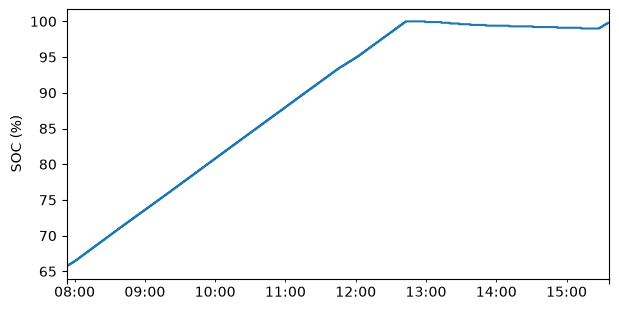

In [4]:
one = frame[frame['session'] == frame['session'].iloc[0]]
ax = one['SOCave292'].plot(figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('SOC (%)')
plt.show()

SOC rises steadily through one slow charge and then holds near 100 percent.